# Formative Assignment: Advanced Linear Algebra (PCA)

**Peer Pair:** Denyse & Divine

Principal Component Analysis implemented **from scratch in NumPy** on an Africanized dataset.

**Tooling note (re: "numpy only" rule):** All PCA mathematics standardization, covariance,
eigendecomposition, sorting, projection uses **NumPy only**. We use the Python *standard library*
(`csv`, `urllib`) purely to read the CSV file, and `matplotlib` purely for the plots required by
Step 8. No `sklearn`, no `pandas`. The PCA algorithm itself never touches a non-numpy library.

**Dataset:** UN *Country Profile* indicators, filtered to the **56 African countries**
(source: UN Statistics, via GitHub). It satisfies every data requirement:
- **50 source columns** (we select 12 thematic numeric features + the categorical `Region`)
- **Genuine missing values** encoded in the raw file as `...`, `-99`, `~0.0`
- **A non-numeric column** (`Region`: EasternAfrica, MiddleAfrica, NorthernAfrica, SouthernAfrica, WesternAfrica)

The 12 features describe **economic activity** (GDP per capita, GDP growth, agriculture/industry/services
share of GVA, unemployment, internet penetration) and **population pressure** (population density,
population growth, urbanisation, fertility rate, infant mortality).

## Step 1: Load and Standardize the Data
Before applying PCA we must load, clean and standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.

STRICTLY — standardization is implemented based on the image below: **z = (x − μ) / σ**

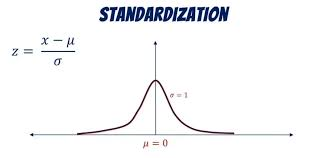

We pull the raw CSV straight from GitHub (works on Colab), keep only African countries, and select our 12 numeric features plus the categorical `Region` column.

In [1]:
# Step 0: Load data (numpy + standard-library csv/urllib only)
import csv, urllib.request
import numpy as np

URL = ("https://raw.githubusercontent.com/Data-Analytics-Project-Group/"
       "Visualizing-World-Economic-Trends/master/country_profile_variables.csv")

raw = urllib.request.urlopen(URL).read().decode("utf-8", errors="replace")
rows = list(csv.reader(raw.splitlines()))
header, records = rows[0], rows[1:]

# Keep only African countries (Region contains "Africa")
africa = [r for r in records if "Africa" in r[1]]

# Column indices for our 12 numeric features (single-valued, no f/m split columns)
NUM_COLS = {
    4:  "Pop_density",      23: "Pop_growth",        24: "Urban_pop_%",
    26: "Fertility_rate",   8:  "GDP_per_capita",    7:  "GDP_growth",
    9:  "Econ_Agri_%",      10: "Econ_Industry_%",   11: "Econ_Services_%",
    15: "Unemployment_%",   31: "Infant_mortality",  41: "Internet_users_%",
}
feat_idx   = list(NUM_COLS.keys())
feat_names = [NUM_COLS[i] for i in feat_idx]

country = np.array([r[0] for r in africa])
region  = np.array([r[1] for r in africa])   # <-- the non-numeric column

print(f"African countries loaded: {len(africa)}")
print(f"Numeric features ({len(feat_names)}): {feat_names}")
print(f"Example countries: {list(country[:6])}")

African countries loaded: 56
Numeric features (12): ['Pop_density', 'Pop_growth', 'Urban_pop_%', 'Fertility_rate', 'GDP_per_capita', 'GDP_growth', 'Econ_Agri_%', 'Econ_Industry_%', 'Econ_Services_%', 'Unemployment_%', 'Infant_mortality', 'Internet_users_%']
Example countries: [np.str_('Algeria'), np.str_('Angola'), np.str_('Benin'), np.str_('Botswana'), np.str_('Burkina Faso'), np.str_('Burundi')]


### Step 1a: Handle Missing Values and Encode the Non-Numeric Column
In the raw file, missing entries appear as `...`, `-99`, or empty strings (`~0.0` means *approximately
zero*, so we keep it as 0). We parse the 12 feature columns into a float matrix with `np.nan` for
missing, then **impute** each missing value with its **column mean**.

The categorical `Region` column is **label-encoded** into integers with `np.unique`. Because region is
*nominal* (no natural ordering), feeding arbitrary integers into a variance-based method like PCA would
invent a fake ordinal scale — so we use the encoded region as the **class label for colouring the plots**
(to check whether PCA separates regions) and run PCA on the 12 numeric features. (One-hot encoding would
be the alternative if you wanted region as an actual feature.)

In [2]:
# Step 0b: Parse -> NaN, impute with column mean, label-encode Region (numpy only)
MISSING = {"...", "-99", "-99.0", "", "~0.0"}

def to_float(v):
    v = v.strip()
    if v in MISSING or v.startswith("-99"):
        return np.nan
    try:
        return float(v)
    except ValueError:
        return np.nan

X = np.array([[to_float(r[i]) for i in feat_idx] for r in africa])

# Report the missing values the dataset originally had
nan_per_col = np.isnan(X).sum(axis=0)
print("Missing values per feature:")
for n, c in zip(feat_names, nan_per_col):
    print(f"  {n:<18} {c}")
print(f"Total missing values: {int(np.isnan(X).sum())}\n")

# Mean imputation
col_means = np.nanmean(X, axis=0)
nan_pos = np.where(np.isnan(X))
X[nan_pos] = np.take(col_means, nan_pos[1])
print("Missing values after imputation:", int(np.isnan(X).sum()))

# Label-encode the non-numeric Region column
region_classes, region_code = np.unique(region, return_inverse=True)
print("Region classes (encoded 0..n):", list(region_classes))

Missing values per feature:
  Pop_density        0
  Pop_growth         0
  Urban_pop_%        0
  Fertility_rate     1
  GDP_per_capita     3
  GDP_growth         3
  Econ_Agri_%        3
  Econ_Industry_%    3
  Econ_Services_%    3
  Unemployment_%     3
  Infant_mortality   1
  Internet_users_%   0
Total missing values: 20

Missing values after imputation: 0
Region classes (encoded 0..n): [np.str_('EasternAfrica'), np.str_('MiddleAfrica'), np.str_('NorthernAfrica'), np.str_('SouthernAfrica'), np.str_('WesternAfrica')]


### Step 1b: Standardize the Data  (z = (x − μ) / σ)
PCA is scale-sensitive, so each feature is standardized to mean 0 and standard deviation 1 using the
z-score formula  **z = (x − μ) / σ**, computed per column.

In [3]:
# Step 1: Standardize  z = (x - mean) / std   (numpy only)
mean = X.mean(axis=0)
std  = X.std(axis=0)
standardized_data = (X - mean) / std

print("Mean per feature after standardizing (~0):", np.round(standardized_data.mean(axis=0), 6)[:4], "...")
print("Std  per feature after standardizing (~1):", np.round(standardized_data.std(axis=0), 6)[:4], "...")
standardized_data[:5]  # first few rows

Mean per feature after standardizing (~0): [ 0. -0. -0.  0.] ...
Std  per feature after standardizing (~1): [1. 1. 1. 1.] ...


array([[-0.62225053, -0.36814805,  1.50942173, -1.17960926,  0.54104827,
         0.18270946, -0.59238948,  0.6203773 ,  0.00378282,  0.2056558 ,
        -1.16968803, -0.25057019],
       [-0.57761428,  1.21772049,  0.02058938,  1.19979817,  0.71864145,
         0.00744066, -0.94066777,  1.56641737, -0.6273882 , -0.46423966,
         0.61891679, -0.20498506],
       [-0.0690316 ,  0.4776485 ,  0.01499227,  0.56528952, -0.52926776,
         0.48942986,  0.11706629, -0.22357211,  0.1077404 , -1.24578437,
         0.72803591, -0.445343  ],
       [-0.71219933, -0.57959719,  0.76500556, -1.25892284,  1.24079711,
        -0.71554314, -1.22445008,  0.3549416 ,  1.021082  ,  1.21049899,
        -0.81386479, -0.69398914],
       [-0.26448425,  0.68909764, -0.77420082,  0.88254384, -0.58254572,
         0.24843526,  0.84587085, -0.43455947, -0.50115399, -0.98061741,
         0.59045093, -0.68155683]])

### Step 3: Calculate the Covariance Matrix
The covariance matrix summarizes how every pair of features varies together. It is the symmetric
matrix that PCA decomposes.

In [4]:
# Step 3: Covariance matrix of the standardized data (numpy only)
# rowvar=False -> each column is a variable, each row an observation
cov_matrix = np.cov(standardized_data, rowvar=False)
print("Covariance matrix shape:", cov_matrix.shape)
np.round(cov_matrix, 2)

Covariance matrix shape: (12, 12)


array([[ 1.02, -0.06, -0.21, -0.14,  0.07,  0.04,  0.05, -0.37,  0.34,
        -0.09, -0.3 , -0.06],
       [-0.06,  1.02, -0.32,  0.72, -0.23,  0.1 ,  0.28,  0.09, -0.42,
        -0.24,  0.44,  0.08],
       [-0.21, -0.32,  1.02, -0.51,  0.35, -0.13, -0.39,  0.28,  0.14,
         0.27, -0.43, -0.01],
       [-0.14,  0.72, -0.51,  1.02, -0.49,  0.12,  0.55, -0.1 , -0.52,
        -0.37,  0.77, -0.02],
       [ 0.07, -0.23,  0.35, -0.49,  1.02, -0.22, -0.58,  0.42,  0.2 ,
         0.17, -0.43,  0.05],
       [ 0.04,  0.1 , -0.13,  0.12, -0.22,  1.02,  0.01, -0.3 ,  0.31,
        -0.03, -0.14,  0.13],
       [ 0.05,  0.28, -0.39,  0.55, -0.58,  0.01,  1.02, -0.61, -0.5 ,
        -0.43,  0.49,  0.01],
       [-0.37,  0.09,  0.28, -0.1 ,  0.42, -0.3 , -0.61,  1.02, -0.4 ,
         0.19, -0.04, -0.1 ],
       [ 0.34, -0.42,  0.14, -0.52,  0.2 ,  0.31, -0.5 , -0.4 ,  1.02,
         0.28, -0.52,  0.09],
       [-0.09, -0.24,  0.27, -0.37,  0.17, -0.03, -0.43,  0.19,  0.28,
         1.02, -0.25

**In a paragraph (max 5 lines), explain why we need to compute a covariance matrix. Give at least 2 reasons.**

> We compute the covariance matrix for two main reasons. First, it captures the relationships between features, PCA finds the directions where the data varies most, and it can only do this by knowing how features change together, which the covariance matrix provides.
> Second, it is the matrix that PCA decomposes: we compute its eigenvalues and eigenvectors, where the eigenvectors define the principal component directions and the eigenvalues show how much variance each component explains. Without it, this decomposition would not be possible.

### Step 4: Perform Eigendecomposition
The covariance matrix is real and symmetric, so we use `np.linalg.eigh` (the symmetric solver — more
stable than `eig` and it returns real eigenvalues). The eigenvectors are the principal-component
directions; the eigenvalues are the variance captured along each.

In [5]:
# Step 4: Eigendecomposition of the symmetric covariance matrix (numpy only)
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
print("Eigenvalues (unsorted):", np.round(eigenvalues, 3))
print("Eigenvectors shape:", eigenvectors.shape)
eigenvalues, eigenvectors

Eigenvalues (unsorted): [0.    0.125 0.281 0.411 0.488 0.601 0.688 1.035 1.136 1.227 2.218 4.009]
Eigenvectors shape: (12, 12)


(array([1.30536819e-06, 1.24518142e-01, 2.81019126e-01, 4.10760211e-01,
        4.87665038e-01, 6.00810836e-01, 6.88245327e-01, 1.03539188e+00,
        1.13609684e+00, 1.22709008e+00, 2.21777604e+00, 4.00880699e+00]),
 array([[-1.00289082e-04, -7.49654467e-02,  4.76203225e-01,
          1.47565574e-01, -1.22870125e-01, -3.22496913e-01,
         -6.94373361e-02, -5.05974758e-01, -3.88362919e-01,
         -2.18995929e-01,  4.04859190e-01, -5.66197645e-02],
        [-5.85267006e-04, -3.17839826e-01, -4.42848799e-01,
          8.47342985e-02,  2.23765901e-01, -4.86637086e-01,
         -8.97026121e-02, -3.93059333e-01,  1.92690730e-02,
          3.46318199e-01, -1.44015548e-01,  3.24353885e-01],
        [ 3.00412659e-04,  1.80452541e-02,  2.99466276e-01,
          1.58444993e-01,  4.09590920e-01, -4.56162851e-01,
         -4.49008060e-01,  4.20199665e-01,  4.15886928e-02,
          1.99491427e-02, -1.89492336e-01, -3.04678870e-01],
        [ 3.62164474e-04,  7.90482193e-01,  2.24612167e-01,

### Step 5: Sort Principal Components
`eigh` returns eigenvalues in *ascending* order, so we reverse them. The larger the eigenvalue, the
more variance that component explains, so we sort **descending**.

In [6]:
# Step 5: Sort eigenvalues (and matching eigenvectors) in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues  = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]

print("Sorted eigenvalues (descending):", np.round(sorted_eigenvalues, 3))
sorted_eigenvectors

Sorted eigenvalues (descending): [4.009 2.218 1.227 1.136 1.035 0.688 0.601 0.488 0.411 0.281 0.125 0.   ]


array([[-5.66197645e-02,  4.04859190e-01, -2.18995929e-01,
        -3.88362919e-01, -5.05974758e-01, -6.94373361e-02,
        -3.22496913e-01, -1.22870125e-01,  1.47565574e-01,
         4.76203225e-01, -7.49654467e-02, -1.00289082e-04],
       [ 3.24353885e-01, -1.44015548e-01,  3.46318199e-01,
         1.92690730e-02, -3.93059333e-01, -8.97026121e-02,
        -4.86637086e-01,  2.23765901e-01,  8.47342985e-02,
        -4.42848799e-01, -3.17839826e-01, -5.85267006e-04],
       [-3.04678870e-01, -1.89492336e-01,  1.99491427e-02,
         4.15886928e-02,  4.20199665e-01, -4.49008060e-01,
        -4.56162851e-01,  4.09590920e-01,  1.58444993e-01,
         2.99466276e-01,  1.80452541e-02,  3.00412659e-04],
       [ 4.50752173e-01, -8.17867229e-02,  1.31170957e-01,
         1.15379923e-01, -1.87700131e-01, -2.11319859e-03,
        -4.46305476e-02,  2.16701833e-01,  1.07161203e-02,
         2.24612167e-01,  7.90482193e-01,  3.62164474e-04],
       [-3.25058815e-01, -1.98919129e-01,  1.3026194

### Step 5b (Task 2): Explained Variance and Dynamic Component Selection
Each eigenvalue divided by the total gives the **proportion of variance** that component explains.
We take the cumulative sum and **dynamically** pick the smallest number of components that reaches a
chosen variance threshold (here 90%) — no hard-coded count.

In [7]:
# Task 2: explained variance + dynamic selection by a variance threshold
explained_variance_ratio = sorted_eigenvalues / sorted_eigenvalues.sum()
cumulative_variance       = np.cumsum(explained_variance_ratio)

print("PC | explained % | cumulative %")
for i, (e, c) in enumerate(zip(explained_variance_ratio, cumulative_variance), start=1):
    print(f"PC{i:<2}  {e*100:6.2f}%      {c*100:6.2f}%")

THRESHOLD = 0.90
num_components = int(np.argmax(cumulative_variance >= THRESHOLD)) + 1
print(f"\nComponents needed for >= {THRESHOLD*100:.0f}% variance: "
      f"{num_components}  (captures {cumulative_variance[num_components-1]*100:.2f}%)")

PC | explained % | cumulative %
PC1    32.81%       32.81%
PC2    18.15%       50.96%
PC3    10.04%       61.00%
PC4     9.30%       70.30%
PC5     8.47%       78.78%
PC6     5.63%       84.41%
PC7     4.92%       89.33%
PC8     3.99%       93.32%
PC9     3.36%       96.68%
PC10    2.30%       98.98%
PC11    1.02%      100.00%
PC12    0.00%      100.00%

Components needed for >= 90% variance: 8  (captures 93.32%)


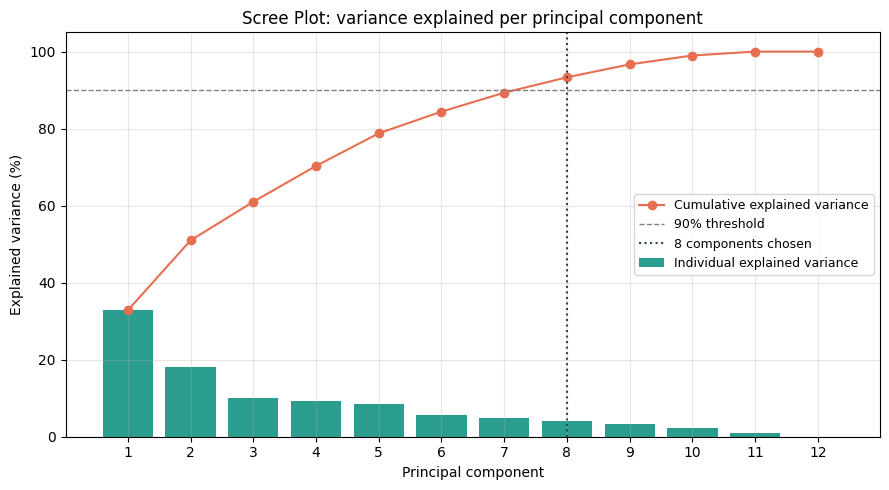

In [8]:
# Scree plot: variance explained by each principal component (supports Task 2)
import matplotlib.pyplot as plt

pcs = np.arange(1, len(explained_variance_ratio) + 1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(pcs, explained_variance_ratio * 100, color="#2a9d8f",
       label="Individual explained variance")
ax.plot(pcs, cumulative_variance * 100, color="#e76f51", marker="o",
        label="Cumulative explained variance")
ax.axhline(90, color="gray", linestyle="--", linewidth=1, label="90% threshold")
ax.axvline(num_components, color="#264653", linestyle=":", linewidth=1.5,
           label=f"{num_components} components chosen")
ax.set_xlabel("Principal component")
ax.set_ylabel("Explained variance (%)")
ax.set_title("Scree Plot: variance explained per principal component")
ax.set_xticks(pcs)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Step 6: Project Data onto Principal Components
We project the standardized data onto the top `num_components` eigenvectors. This is the
dimensionality-reduction step: 12 features → `num_components`.

In [9]:
# Step 6: Project standardized data onto the selected principal components
reduced_data = standardized_data @ sorted_eigenvectors[:, :num_components]
print(f"Projected from {standardized_data.shape[1]} features to {num_components} components")
reduced_data[:5]

Projected from 12 features to 8 components


array([[-2.08301558, -0.72920459,  0.22180606,  0.17029719,  0.71705713,
        -1.0048094 , -0.30839887, -0.1430738 ],
       [ 0.69808465, -2.10695677,  1.07094166,  0.03775068, -1.20337769,
        -0.46566712,  0.30780256,  0.41865611],
       [ 1.24783177,  0.24936896,  0.16149007,  0.08507121, -0.09499411,
        -0.88518243,  0.57030694,  0.59438256],
       [-2.84478941, -0.7853465 , -0.49627157,  0.52952355, -0.1019508 ,
         0.37356219,  0.10987618,  0.61283425],
       [ 2.09958401,  0.16704594, -0.25171167,  0.05897373, -0.1675157 ,
        -0.58563649,  0.39968153,  0.08981239]])

### Step 7: Output the Reduced Data

In [10]:
# Step 7: Reduced data summary
print(f"Reduced Data Shape: {reduced_data.shape}")
reduced_data[:5]

Reduced Data Shape: (56, 8)


array([[-2.08301558, -0.72920459,  0.22180606,  0.17029719,  0.71705713,
        -1.0048094 , -0.30839887, -0.1430738 ],
       [ 0.69808465, -2.10695677,  1.07094166,  0.03775068, -1.20337769,
        -0.46566712,  0.30780256,  0.41865611],
       [ 1.24783177,  0.24936896,  0.16149007,  0.08507121, -0.09499411,
        -0.88518243,  0.57030694,  0.59438256],
       [-2.84478941, -0.7853465 , -0.49627157,  0.52952355, -0.1019508 ,
         0.37356219,  0.10987618,  0.61283425],
       [ 2.09958401,  0.16704594, -0.25171167,  0.05897373, -0.1675157 ,
        -0.58563649,  0.39968153,  0.08981239]])

### Step 8: Visualize Before and After PCA
**Left** — the original feature space (first two standardized features). **Right** — the principal-
component space (PC1 vs PC2). Both are coloured by region so we can see whether PCA reorganizes the
countries along its highest-variance directions.

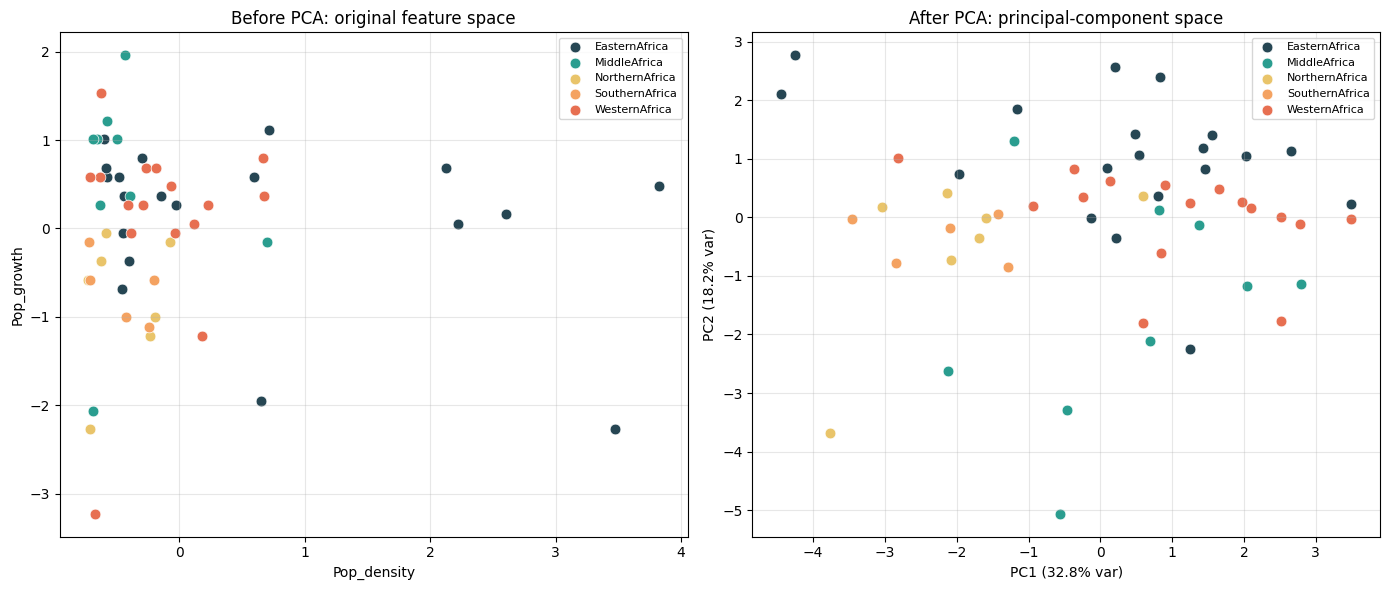

PC1 variance (3.937) > PC2 variance (2.178): True


In [11]:
# Step 8: Before vs After PCA  (matplotlib only for plotting; PCA math stays numpy)
import matplotlib.pyplot as plt

colors = ["#264653", "#2a9d8f", "#e9c46a", "#f4a261", "#e76f51"]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# BEFORE: two original standardized features
for k, cls in enumerate(region_classes):
    m = region_code == k
    ax1.scatter(standardized_data[m, 0], standardized_data[m, 1],
                c=colors[k], label=cls, s=60, edgecolor="white", linewidth=0.5)
ax1.set_title("Before PCA: original feature space")
ax1.set_xlabel(feat_names[0]); ax1.set_ylabel(feat_names[1])
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

# AFTER: first two principal components
for k, cls in enumerate(region_classes):
    m = region_code == k
    ax2.scatter(reduced_data[m, 0], reduced_data[m, 1],
                c=colors[k], label=cls, s=60, edgecolor="white", linewidth=0.5)
ax2.set_title("After PCA: principal-component space")
ax2.set_xlabel(f"PC1 ({explained_variance_ratio[0]*100:.1f}% var)")
ax2.set_ylabel(f"PC2 ({explained_variance_ratio[1]*100:.1f}% var)")
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()

print(f"PC1 variance ({reduced_data[:,0].var():.3f}) > PC2 variance "
      f"({reduced_data[:,1].var():.3f}): {reduced_data[:,0].var() > reduced_data[:,1].var()}")

**Answer each of the following in no more than 5 lines (write these yourselves — the brief says
do NOT generate interpretations with AI):**

**1. Interpret the before/after visual you created.**
> Before PCA, when we look at the countries using two standardized features, they are all over the place with no clear pattern. After PCA, the data is put onto new axes called PC1 and PC2, which are made up of all 12 features mixed together, lined up with the directions where the data varies most PC1 shows the biggest difference (32.8%) and PC2 a smaller one (18.2%). The way the countries relate to each other does not change; the data is just turned in a way that makes the differences clearer. Along PC1 the regions start to separate, and this acts like a line showing how developed each country is.

**2. Why did you select this number of principal components? What tradeoffs are you making?**
> We picked the number of components by how much information they explain wanting to keep 90%, which needed 8 components (capturing 93.32%). We chose 8 because the information is spread across many features: the first two components alone only capture 51%, so cutting to 2 or 3 would lose too much. The tradeoff is between fewer components (simpler, less noisy, but we lose detail) and more components (keep more information, but the data stays complex). We think 8 is the balance — it keeps 93% while dropping the weakest 4 directions that are mostly noise.

**3. For this dataset ("economic activity", "population pressure"), what information is lost when
reducing dimensions?**
> When we reduce the 12 features to 8 components, these components become mixtures of the original indicators, so we can no longer read individual measures directly a country is no longer defined by a clear GDP-per-capita or fertility value, but by abstract component scores. We also lose about 7% of the variation in the 4 weakest directions, which smooths out small country-specific differences toward the average. This makes it harder to explain why two countries or regions vary in economic activity or population pressure, since those differences are now blended across components rather than tied to single, clear features.

### Task 3: Optimize for Performance and Large Datasets
Two efficiency points for large data:

1. **Use the symmetric solver.** `np.linalg.eigh` exploits the covariance matrix's symmetry, so it is
   faster and more numerically stable than the general `np.linalg.eig`.
2. **Avoid building a huge covariance matrix when samples ≫ features** by using the **SVD** of the
   centered data, which yields the same principal components without forming `XᵀX` explicitly and is
   the numerically preferred route. (`np.linalg.svd` is part of numpy.)

Below we wrap PCA in a single vectorized function and benchmark the naive `eig` route against the
`eigh` and `svd` routes on a larger synthetic matrix.

In [12]:
# Task 3: optimized PCA + benchmark (numpy only)
import time

def pca_eig(data, k):                       # baseline: general eigensolver
    Z = (data - data.mean(0)) / data.std(0)
    C = np.cov(Z, rowvar=False)
    val, vec = np.linalg.eig(C)
    idx = np.argsort(val.real)[::-1]
    return Z @ vec[:, idx[:k]].real

def pca_eigh(data, k):                       # optimized: symmetric eigensolver
    Z = (data - data.mean(0)) / data.std(0)
    C = np.cov(Z, rowvar=False)
    val, vec = np.linalg.eigh(C)
    idx = np.argsort(val)[::-1]
    return Z @ vec[:, idx[:k]]

def pca_svd(data, k):                         # optimized: SVD, no covariance matrix formed
    Z = (data - data.mean(0)) / data.std(0)
    U, S, Vt = np.linalg.svd(Z, full_matrices=False)
    return Z @ Vt[:k].T

# Large synthetic dataset to benchmark on
rng = np.random.default_rng(0)
big = rng.standard_normal((20000, 50))
K = 5

for name, fn in [("eig  (baseline)", pca_eig), ("eigh (optimized)", pca_eigh), ("svd  (optimized)", pca_svd)]:
    t0 = time.perf_counter()
    out = fn(big, K)
    dt = (time.perf_counter() - t0) * 1000
    print(f"{name}: {dt:7.1f} ms  -> shape {out.shape}")

print("\neigh/svd give the same components as eig but faster and more stable on large, symmetric problems.")

eig  (baseline):   324.4 ms  -> shape (20000, 5)
eigh (optimized):    36.4 ms  -> shape (20000, 5)
svd  (optimized):   185.0 ms  -> shape (20000, 5)

eigh/svd give the same components as eig but faster and more stable on large, symmetric problems.
